In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

In [2]:
df= pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.shape

(4269, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [6]:
df[" loan_status"].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [7]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [8]:
numerical_cols = [' no_of_dependents', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
                  ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value']

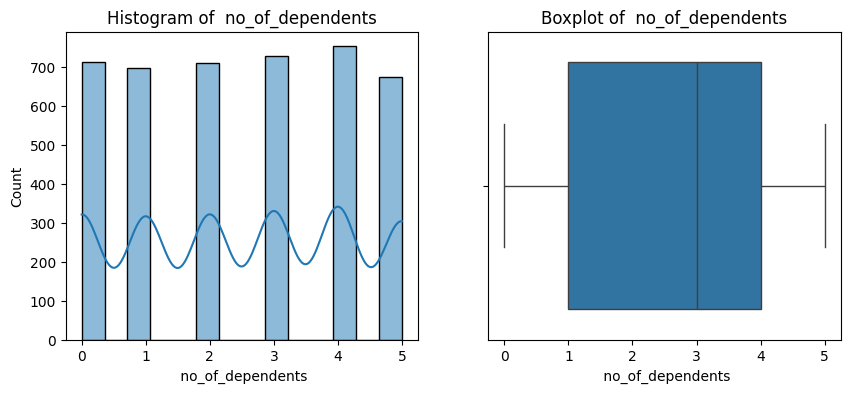

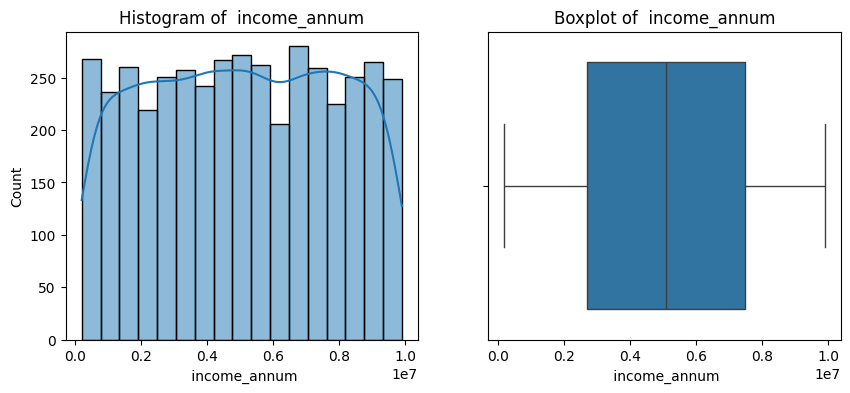

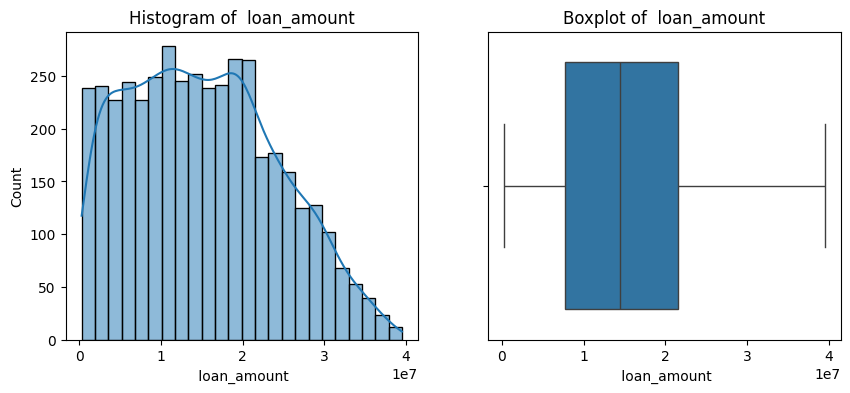

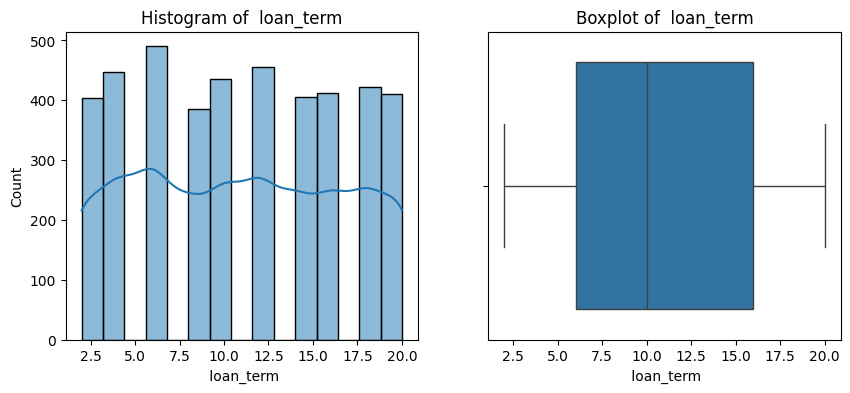

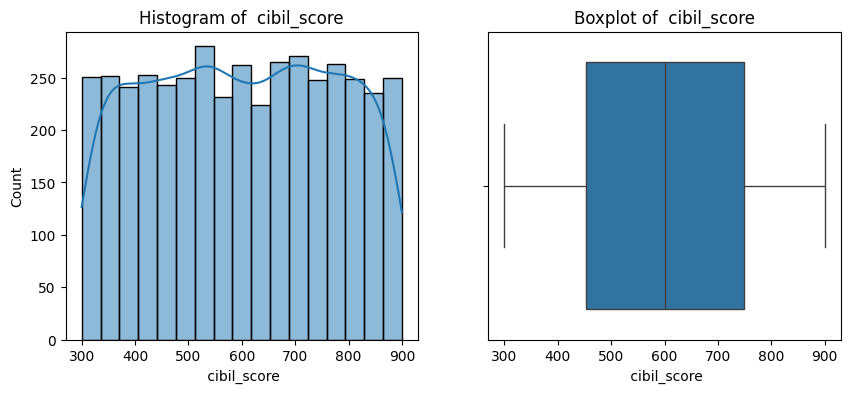

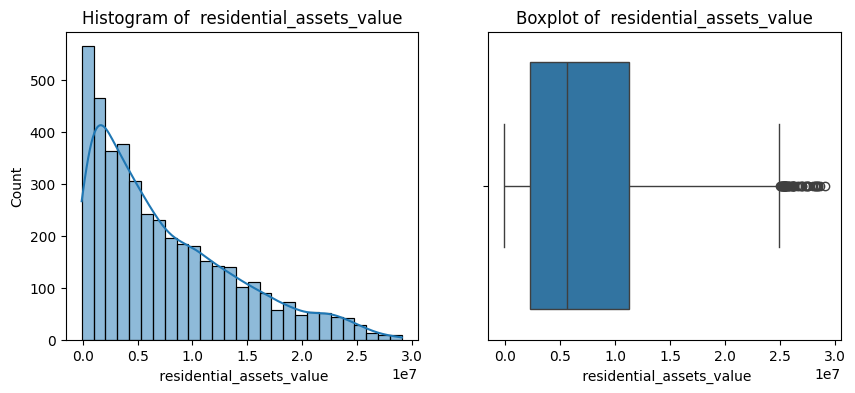

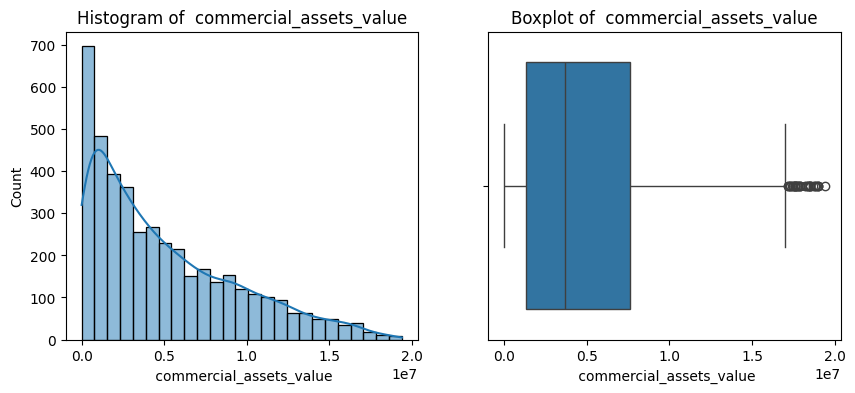

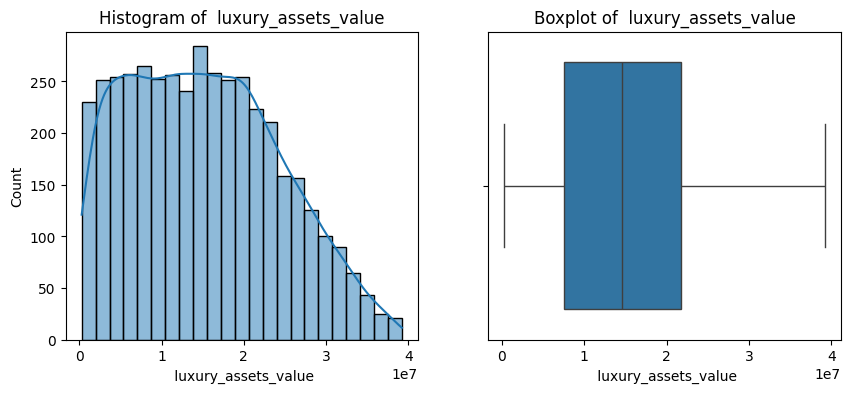

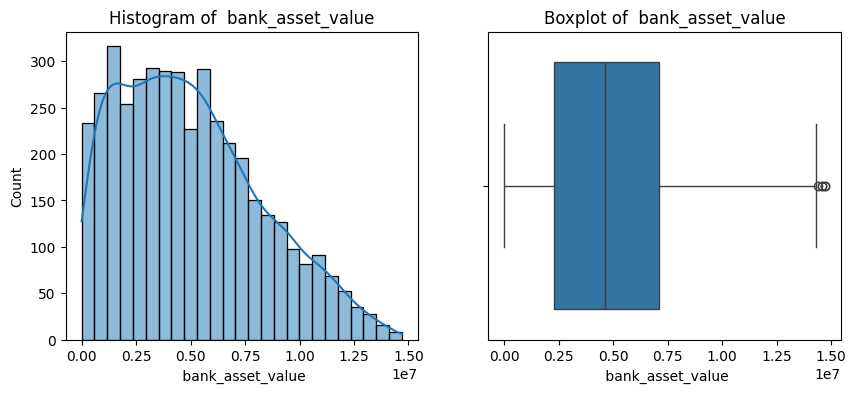

In [9]:


for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

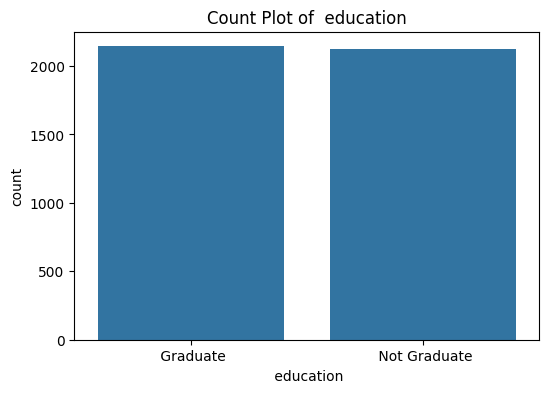

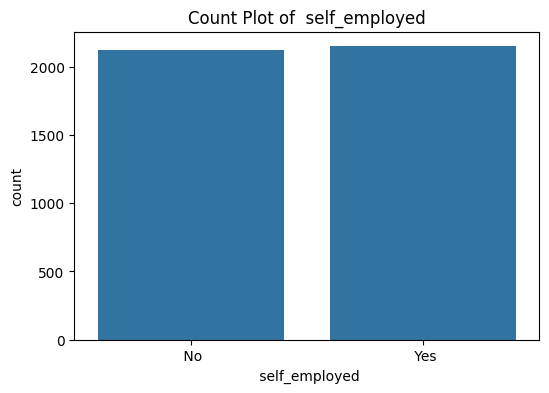

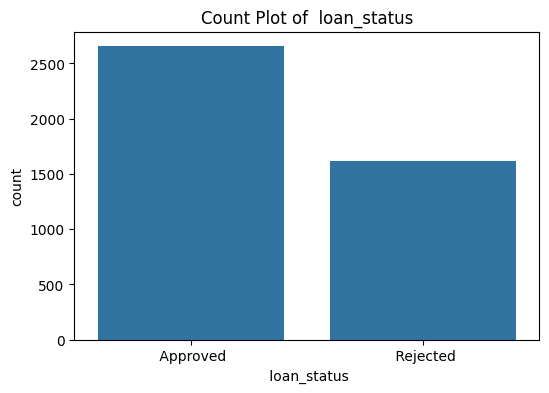

In [10]:
categorical_cols = [' education', ' self_employed', ' loan_status']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[col])
    plt.title(f'Count Plot of {col}')
    plt.show()

 loan_status  Approved  Rejected
 education                      
Graduate      0.624534  0.375466
Not Graduate  0.619765  0.380235


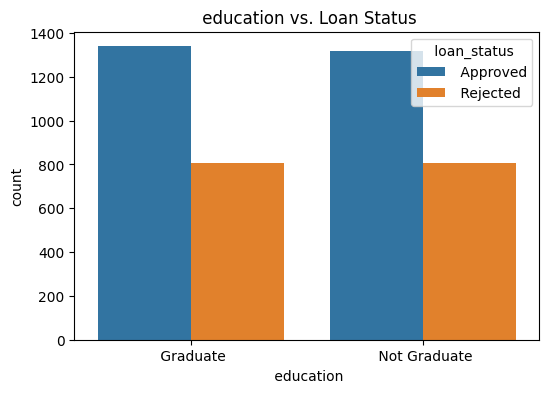

 loan_status    Approved  Rejected
 self_employed                    
No              0.621992  0.378008
Yes             0.622326  0.377674


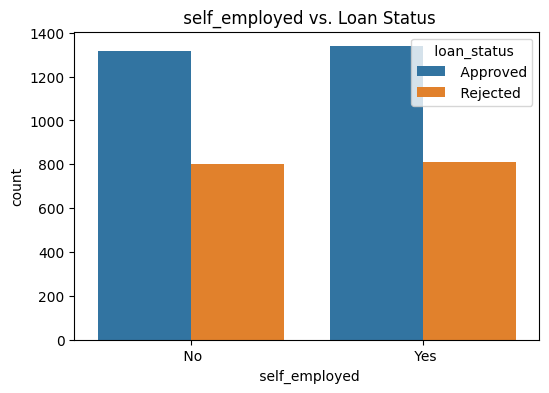

In [11]:
for col in [' education', ' self_employed']:
    print(pd.crosstab(df[col], df[' loan_status'], normalize='index'))  # Proportions
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue=' loan_status', data=df)
    plt.title(f'{col} vs. Loan Status')
    plt.show()

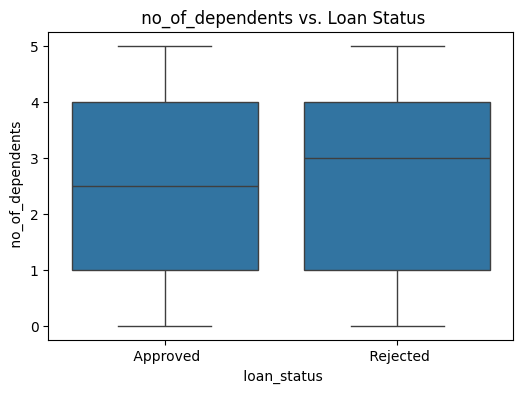

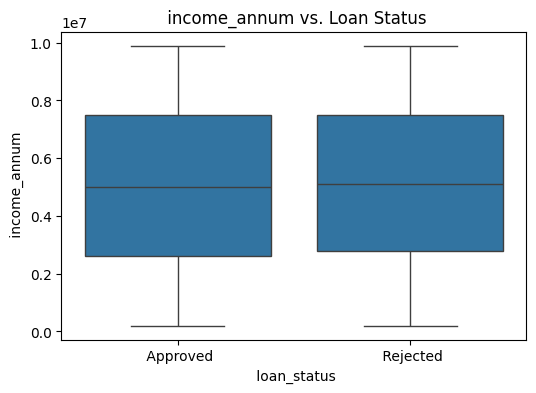

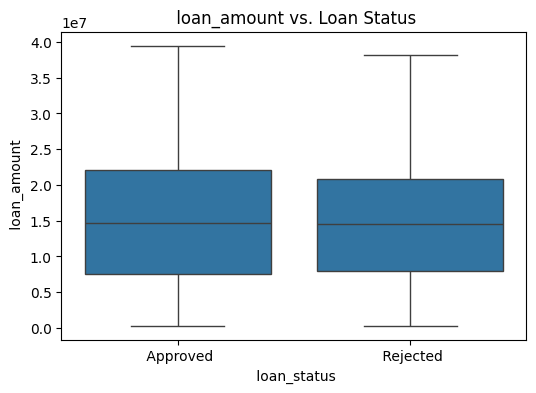

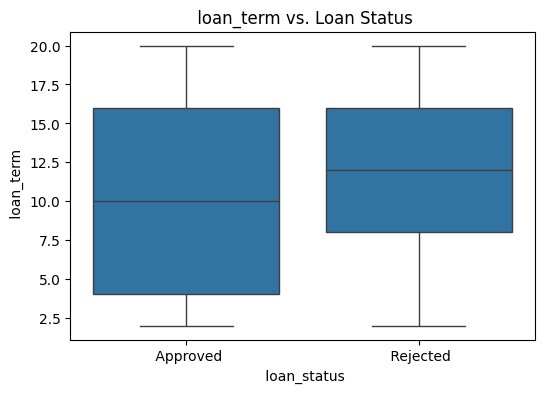

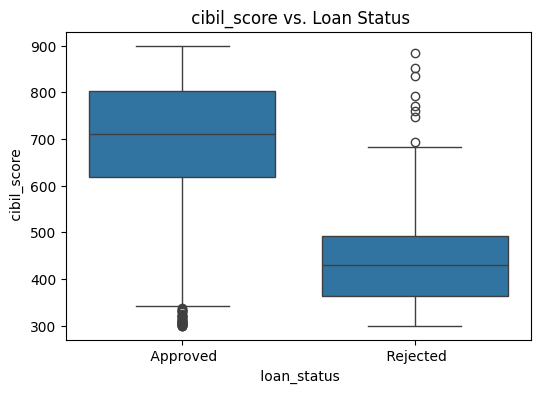

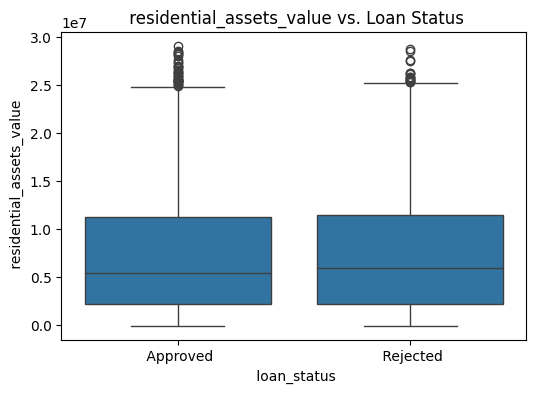

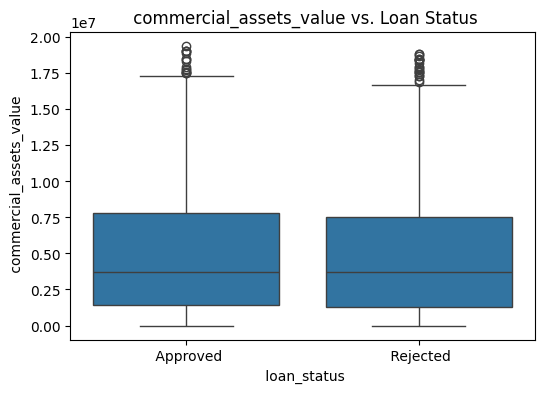

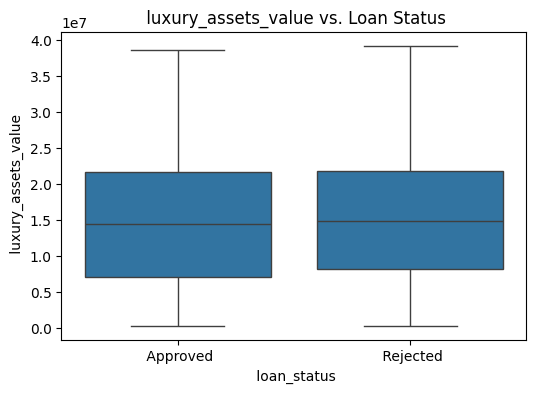

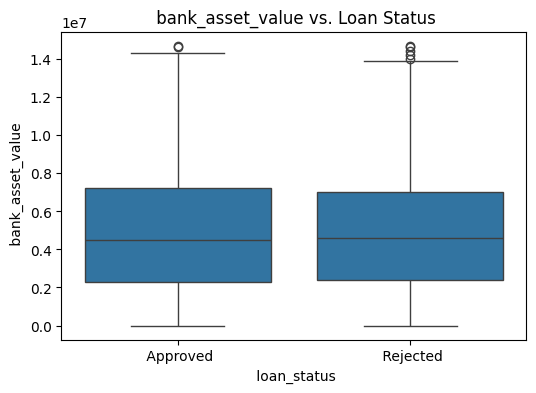

In [12]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=' loan_status', y=col, data=df)
    plt.title(f'{col} vs. Loan Status')
    plt.show()

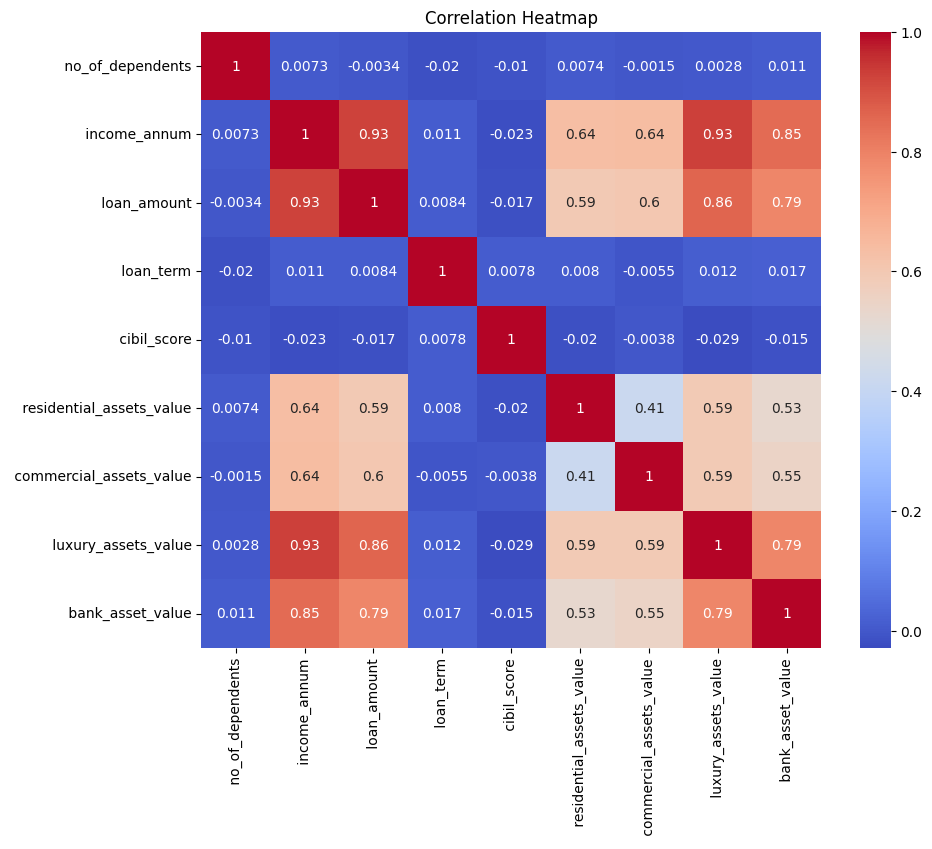

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f'Outliers in {col}: {len(outliers)}')


Outliers in  no_of_dependents: 0
Outliers in  income_annum: 0
Outliers in  loan_amount: 0
Outliers in  loan_term: 0
Outliers in  cibil_score: 0
Outliers in  residential_assets_value: 52
Outliers in  commercial_assets_value: 37
Outliers in  luxury_assets_value: 0
Outliers in  bank_asset_value: 5


In [15]:
df = df.drop('loan_id', axis=1)

In [16]:
le = LabelEncoder()
df[' education'] = le.fit_transform(df[' education']) 
df[' self_employed'] = le.fit_transform(df[' self_employed'])  
df[' loan_status'] = le.fit_transform(df[' loan_status'])

In [17]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [18]:
X = df.drop(' loan_status', axis=1)
y = df[' loan_status']

In [19]:
y.head()

0    0
1    1
2    1
3    1
4    1
Name:  loan_status, dtype: int32

In [20]:
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
X.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,-0.294102,0,0,1.617979,1.633052,0.192617,1.032792,-0.780058,2.877289,0.832028,0.930304
1,-1.473548,1,1,-0.341750,-0.324414,-0.508091,-1.061051,-0.733924,-0.631921,-0.694993,-0.515936
2,0.295621,0,0,1.439822,1.610933,1.594031,-0.544840,-0.057300,-0.107818,1.996520,2.407316
3,0.295621,0,0,1.119139,1.721525,-0.508091,-0.771045,1.649637,-0.381263,0.897943,0.899533
4,1.475067,1,1,1.689242,1.002681,1.594031,-1.264055,0.757724,0.735304,1.568075,0.007172


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32, stratify=y)

In [22]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [23]:
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr)}')
print(f'Precision: {precision_score(y_test, y_pred_lr)}')
print(f'Recall: {recall_score(y_test, y_pred_lr)}')
print(f'F1 Score: {f1_score(y_test, y_pred_lr)}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_lr)}')

Accuracy: 0.9039812646370023
Precision: 0.887459807073955
Recall: 0.8544891640866873
F1 Score: 0.8706624605678234
ROC-AUC: 0.8942878965442853


In [24]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


In [25]:
print(f'Accuracy: {accuracy_score(y_test, y_pred_dt)}')
print(f'Precision: {precision_score(y_test, y_pred_dt)}')
print(f'Recall: {recall_score(y_test, y_pred_dt)}')
print(f'F1 Score: {f1_score(y_test, y_pred_dt)}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_dt)}')

Accuracy: 0.9847775175644028
Precision: 0.984375
Recall: 0.9752321981424149
F1 Score: 0.9797822706065319
ROC-AUC: 0.9829080011427705


In [26]:
metrics = {
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_dt)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_dt)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_dt)]
}
metrics_df = pd.DataFrame(metrics)

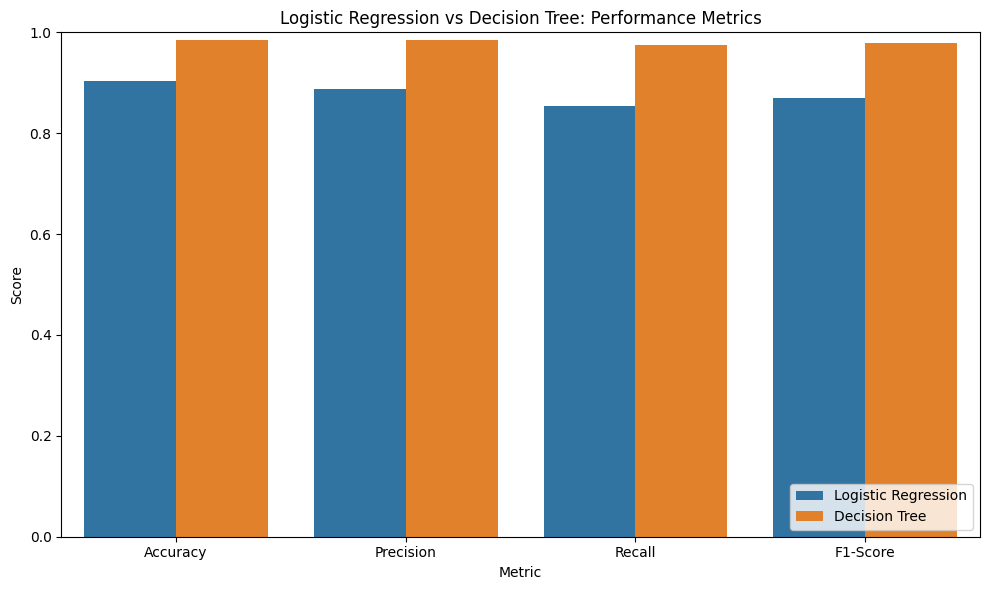

In [27]:
metrics_melted = pd.melt(metrics_df, id_vars=['Model'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                         var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted, palette=['#1f77b4', '#ff7f0e'])
plt.title('Logistic Regression vs Decision Tree: Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

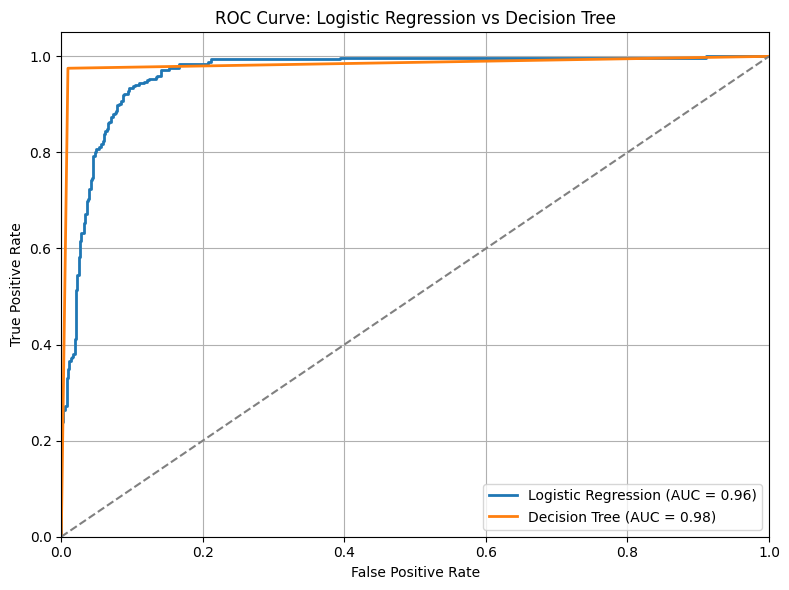

In [28]:
y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_dt = dt.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='#1f77b4', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, color='#ff7f0e', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression vs Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
df_seg=X.copy()

In [30]:
df_seg.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,-0.294102,0,0,1.617979,1.633052,0.192617,1.032792,-0.780058,2.877289,0.832028,0.930304
1,-1.473548,1,1,-0.341750,-0.324414,-0.508091,-1.061051,-0.733924,-0.631921,-0.694993,-0.515936
2,0.295621,0,0,1.439822,1.610933,1.594031,-0.544840,-0.057300,-0.107818,1.996520,2.407316
3,0.295621,0,0,1.119139,1.721525,-0.508091,-0.771045,1.649637,-0.381263,0.897943,0.899533
4,1.475067,1,1,1.689242,1.002681,1.594031,-1.264055,0.757724,0.735304,1.568075,0.007172


In [31]:
clusters = 4  
kmeans = KMeans(n_clusters=clusters, random_state=42)
df_seg['Cluster'] = kmeans.fit_predict(df_seg)

df['Cluster'] = df_seg['Cluster']

In [32]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,Cluster
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,3
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,2
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,3
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,3
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,3


In [33]:
df[' loan_status'] = le.inverse_transform(df[' loan_status'])


 loan_status  Approved  Rejected
Cluster                         
0             0.634865  0.365135
1             0.594893  0.405107
2             0.631579  0.368421
3             0.640839  0.359161


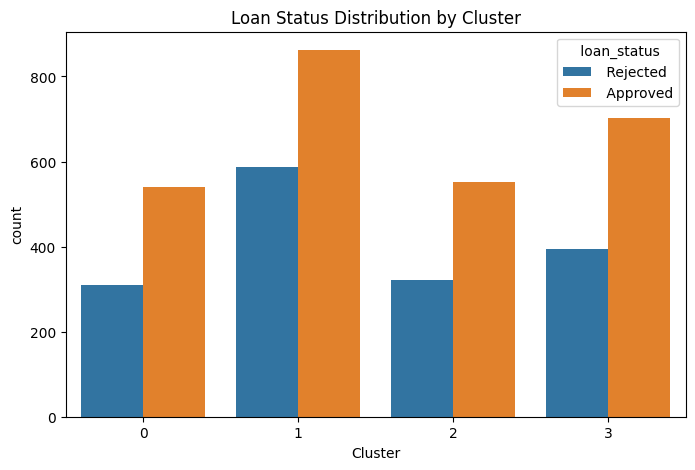

In [34]:
print(pd.crosstab(df['Cluster'], df[' loan_status'], normalize='index'))

plt.figure(figsize=(8, 5))
sns.countplot(x='Cluster', hue=' loan_status', data=df)
plt.title('Loan Status Distribution by Cluster')
plt.show()

In [35]:
df['Cluster'].value_counts()

Cluster
1    1449
3    1097
2     874
0     849
Name: count, dtype: int64

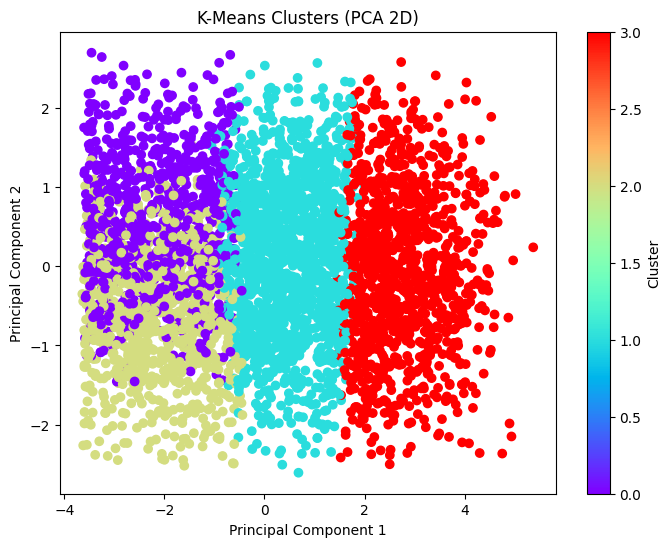

In [36]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(df_seg.drop(columns=['Cluster']))

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=df_seg['Cluster'], cmap='rainbow')
plt.title('K-Means Clusters (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()